In [1]:
import os
import tqdm
os.chdir('../../..')
folder = 'trained_models/mean_embeddings'
os.getcwd()

'/Users/nkapila6/Code/nlpvise/src'

In [2]:
from skorch import NeuralNetClassifier
from models.convlstm import ConvLSTM
from models.convnet import ConvNet
from models.bilstm import BiLSTM
from models.mlp import mlp
from models.moe import MoE

In [3]:
def load_model(module, param_path):
    net = NeuralNetClassifier(module=module)
    net.initialize()
    net.load_params(f_params=param_path)

    return net.module_

In [4]:
experts = {}
with os.scandir(folder) as entries:
    for entry in entries:
        print(entry.name)
        module = None
        match entry.name:
            case 'BiLSTM_MEAN.pkl':
                module = load_model(module=BiLSTM(input_size=768), param_path=entry.path)
                experts['bilstm'] = module
            case 'mlp_MEAN.pkl':
                module = load_model(module=mlp(input_size=768), param_path=entry.path)
                experts['mlp'] = module
            case 'ConvLSTM_MEAN.pkl':
                module = load_model(module=ConvLSTM(input_size=768), param_path=entry.path)
                experts['convlstm'] = module
            case 'ConvNet_MEAN.pkl':
                module = load_model(module=ConvNet(input_size=768), param_path=entry.path)
                experts['convnet'] = module

.DS_Store
mlp_MEAN.pkl
ConvNet_MEAN.pkl
BiLSTM_MEAN.pkl
ConvLSTM_MEAN.pkl


In [5]:
experts

{'mlp': mlp(
   (fc1): Linear(in_features=768, out_features=75, bias=True)
   (fc2): Linear(in_features=75, out_features=19, bias=True)
 ),
 'convnet': ConvNet(
   (fc1): Linear(in_features=768, out_features=289, bias=True)
   (conv1): Conv2d(1, 19, kernel_size=(3, 3), stride=(1, 1))
   (fc2): Linear(in_features=4275, out_features=19, bias=True)
 ),
 'bilstm': BiLSTM(
   (fc1): Linear(in_features=768, out_features=289, bias=True)
   (lstm): LSTM(289, 300, bidirectional=True)
   (fc2): Linear(in_features=600, out_features=19, bias=True)
 ),
 'convlstm': ConvLSTM(
   (fc1): Linear(in_features=768, out_features=289, bias=True)
   (conv1): Conv2d(1, 19, kernel_size=(3, 3), stride=(1, 1))
   (fc2): Linear(in_features=4275, out_features=289, bias=True)
   (lstm): LSTM(289, 300)
   (fc3): Linear(in_features=300, out_features=19, bias=True)
 )}

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import accuracy_score

def evaluate_multi_label(y_true, y_probs, threshold=0.6):
    y_pred = (y_probs > threshold).astype(int)
    
    per_class_acc = []
    # per_class_mcc = []

    for i in range(y_true.shape[1]):
        per_class_acc.append(accuracy_score(y_true[:, i], y_pred[:, i]))
        # per_class_mcc.append(matthews_corrcoef(y_true[:, i], y_pred[:, i]))

    results = {
        'accuracy': np.mean(per_class_acc),
        # 'mcc': np.mean(per_class_mcc),
        # 'f1': f1_score(y_true, y_pred, average='weighted'),
        # 'auprc': average_precision_score(y_true, y_probs),
        # 'auroc': roc_auc_score(y_true, y_probs)
    }
    # return results
    return np.mean(per_class_acc)

def train_model_torch(model, X_train, y_train, X_test, y_test,
                      lr=0.001, batch_size=128, epochs=8, device='cpu'):
    accuracies = []
    gate_tracking = []
    expert_names = model.expert_names
    w_dict = {name: [] for name in expert_names}

    model = model.to(device)
    X_train = torch.tensor(X_train, dtype=torch.float32).to(device)
    y_train = torch.tensor(y_train, dtype=torch.float32).to(device)
    X_test = torch.tensor(X_test, dtype=torch.float32).to(device)
    y_test = torch.tensor(y_test, dtype=torch.float32).to(device)

    train_dataset = TensorDataset(X_train, y_train)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    # loss and optimizer
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.gating_network.parameters(), lr=lr) #1e-3

    # Training loop
    for epoch in range(epochs):
        model.train()
        epoch_loss = 0
        
        for batch_X, batch_y in train_loader:
            optimizer.zero_grad()
            # outputs, _ = model(batch_X).squeeze()
            outputs, _, _ = model(batch_X)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        avg_loss = epoch_loss / len(train_loader)
        print(f"Epoch {epoch+1}/{epochs} | Loss: {avg_loss:.4f}")

        # Evaluation
        with torch.no_grad():
            model.eval()
            logits, gate_weights, gate_dict = model(X_test)
            
            probs = torch.sigmoid(logits).cpu().numpy()
            y_test_np = y_test.cpu().numpy()
            acc = evaluate_multi_label(y_test_np, probs)
            accuracies.append(acc)
            print(f"Accuracy {acc}")

            avg_gate_usage = gate_weights.mean(dim=0).cpu().numpy()
            gate_tracking.append(avg_gate_usage)
            print("Avg expert weights:", avg_gate_usage)

            # epoch wise dict
            for name, val in gate_dict.items():
                w_dict[name].append(val)

    return model, accuracies, gate_tracking, w_dict

In [7]:
import pickle
with open("data/X_MEAN.pkl", "rb") as f:
    X = pickle.load(f)

with open("data/y_MEAN.pkl", "rb") as f:
    y = pickle.load(f)

In [8]:
from sklearn.model_selection import train_test_split

moe_model = MoE(experts=experts, input_dim=768, hidden_dim=128)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

device = 'mps' if torch.backends.mps.is_available() else 'cuda' if torch.cuda.is_available() else 'cpu'

trained_model, acc, gate_track, w_dict = train_model_torch(
    model=moe_model,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    lr=1e-3,
    batch_size=128,
    epochs=8,
    device=device
)

print(f"✅ Mean Accuracy: {np.mean(acc):.4f} ± {np.std(acc):.4f}")

Epoch 1/8 | Loss: 0.4224
Accuracy 0.78930702309923
Avg expert weights: [6.3838105e-04 8.1120826e-02 7.0262390e-01 2.1561687e-01]
Epoch 2/8 | Loss: 0.4221
Accuracy 0.7895347932846682
Avg expert weights: [5.6123111e-04 1.1094387e-01 6.4642137e-01 2.4207354e-01]
Epoch 3/8 | Loss: 0.4222
Accuracy 0.7894310930376395
Avg expert weights: [0.00162085 0.19782051 0.61557    0.18498868]
Epoch 4/8 | Loss: 0.4220
Accuracy 0.7895940505686848
Avg expert weights: [0.00308271 0.13032407 0.56541395 0.30117926]
Epoch 5/8 | Loss: 0.4220
Accuracy 0.7895959023588103
Avg expert weights: [0.00116449 0.10042095 0.62946707 0.26894754]
Epoch 6/8 | Loss: 0.4219
Accuracy 0.7896903436552115
Avg expert weights: [0.00349371 0.15152696 0.5955473  0.24943197]
Epoch 7/8 | Loss: 0.4219
Accuracy 0.7897218240873451
Avg expert weights: [3.8255547e-04 1.2634565e-01 5.5534065e-01 3.1793112e-01]
Epoch 8/8 | Loss: 0.4219
Accuracy 0.7894588698895222
Avg expert weights: [0.00571691 0.16658887 0.6606931  0.1670011 ]
✅ Mean Accurac

In [9]:
# saving model
torch.save(moe_model, 'trained_models/mean_embeddings/moe_model_cls.pth')

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

def plot_expert_weights_over_epochs(epoch_w_dict:dict, title):
    epochs = range(1, len(list(epoch_w_dict.values())[0]) + 1)
    
    for expert_name, weights in epoch_w_dict.items():
        plt.plot(epochs, weights, marker='o', label=expert_name)
    
    plt.xlabel('Epoch')
    plt.ylabel('Mean Expert Weight')
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    return plt

def plot_expert_distribution(gate_track, expert_names, title):
    gate_data = np.array(gate_track)
    plt.boxplot(gate_data, label=expert_names)
    plt.ylabel('Weight')
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    return plt

def plot_expert_heatmap(gate_track, expert_names, title):
    gate_data = np.array(gate_track)
    colors = [(0.95, 0.95, 0.95), (0.8, 0.8, 1), (0, 0.5, 1)]
    cmap = LinearSegmentedColormap.from_list('blue_gradient', colors, N=256)
    
    sns.heatmap(gate_data, cmap=cmap, annot=True, fmt=".3f", 
                xticklabels=expert_names, yticklabels=range(1, len(gate_track)+1))
    
    plt.xlabel('Experts')
    plt.ylabel('Epoch')
    plt.title(title)
    plt.tight_layout()
    return plt

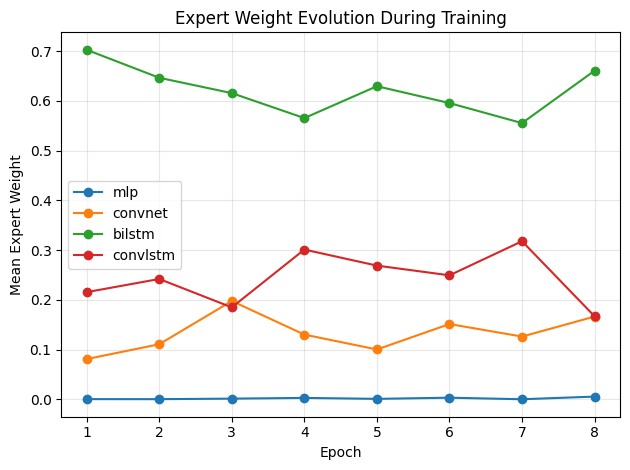

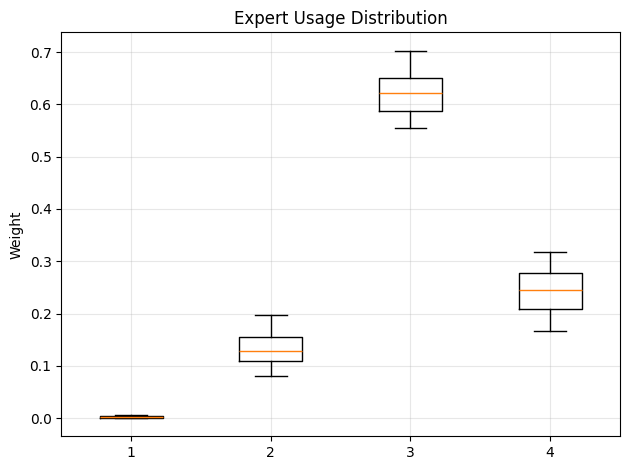

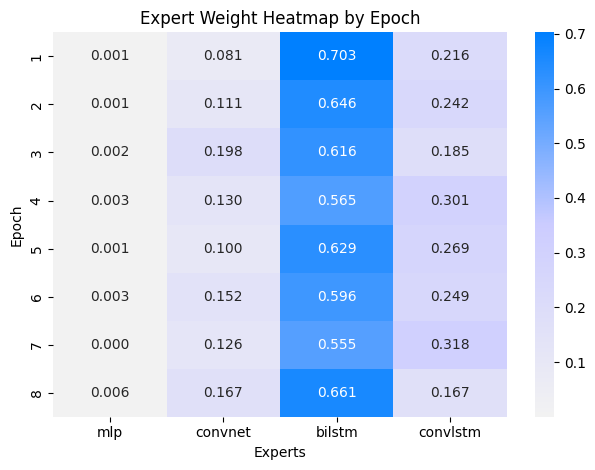

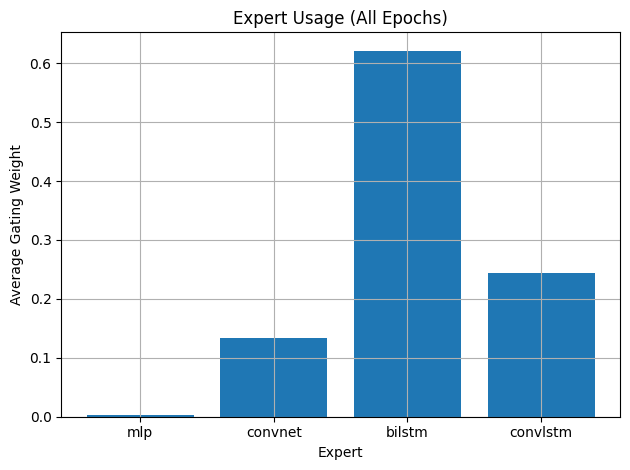

In [11]:
plt1 = plot_expert_weights_over_epochs(w_dict, title="Expert Weight Evolution During Training")
plt1.savefig('../plots/moe-mean-usage/expert_weights_evolution.png')
plt.show()

# plot expert dist
plt2 = plot_expert_distribution(gate_track, moe_model.expert_names, title="Expert Usage Distribution")
plt2.savefig('../plots/moe-mean-usage/expert_distribution.png')
plt.show()

# heatmap over epochs
plt3 = plot_expert_heatmap(gate_track, moe_model.expert_names, title="Expert Weight Heatmap by Epoch")
plt3.savefig('../plots/moe-mean-usage/expert_heatmap.png')
plt.show()

# expert usage over epochs - bar chart
avg_usage = {k: np.mean(v) for k, v in w_dict.items()}
plt.bar(avg_usage.keys(), avg_usage.values())
plt.title("Expert Usage (All Epochs)")
plt.xlabel("Expert")
plt.ylabel("Average Gating Weight")
plt.grid(True)
plt.tight_layout()
plt.savefig('../plots/moe-mean-usage/expert_usage_all_epochs.png')
plt.show()

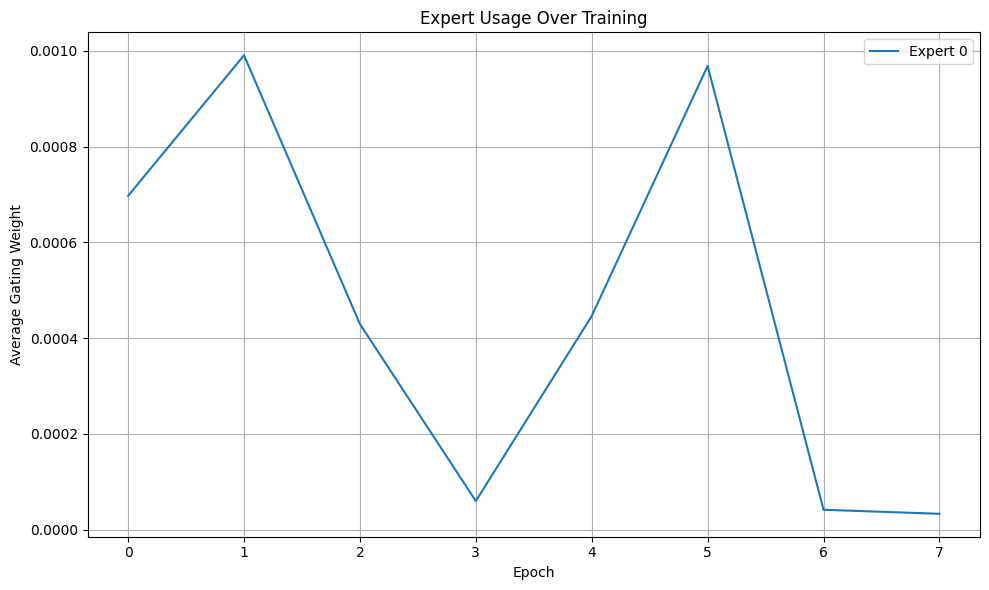

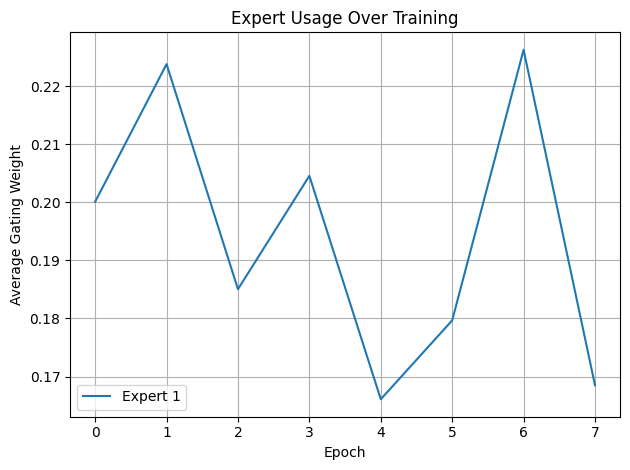

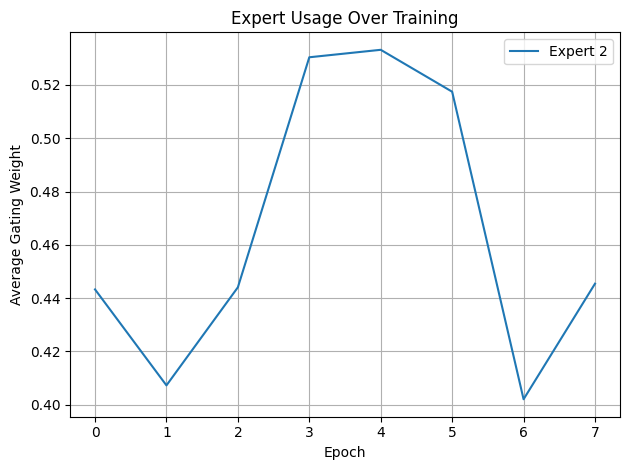

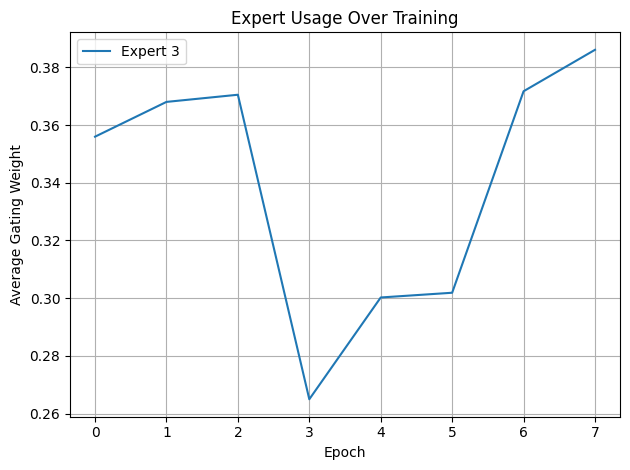

In [ ]:
import matplotlib.pyplot as plt
gate_tracking = np.stack(gate_track)  # shape: [epochs, num_experts]
num_experts = gate_tracking.shape[1]

plt.figure(figsize=(10, 6))
for i in range(num_experts):
    plt.plot(gate_tracking[:, i], label=f'Expert {i}')
    plt.xlabel("Epoch")
    plt.ylabel("Average Gating Weight")
    plt.title("Expert Usage Over Training")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


# eval

In [12]:
from sklearn.metrics import f1_score, roc_auc_score, average_precision_score, accuracy_score, matthews_corrcoef

def eval_model(pytorchmodel, X_test, y_test, threshold=0.5):
        # spitting out pytorch model from skorch module
        # pytorchmodel = model.module_
        # pytorchmodel = pytorchmodel.cpu() # moving to cpu as I use mps
        # pytorchmodel.to(self.device)
        device = 'mps' if torch.backends.mps.is_available() else 'cuda' if torch.cuda.is_available() else 'cpu'
        X_test = torch.tensor(X_test, dtype=torch.float32).to(device)
        y_test = torch.tensor(y_test, dtype=torch.float32).to(device)

        
        pytorchmodel.eval() # model in eval mode
        with torch.no_grad():
            logits,_,_ = pytorchmodel.forward(X_test)
            
        X_test = X_test.cpu()
        y_test = y_test.cpu()
        y_probs = torch.sigmoid(logits).cpu().numpy()
        y_pred = (y_probs > threshold).astype(int)

        _acc = [accuracy_score(y_test[:, i], y_pred[:, i]) for i in range(y_test.shape[1])]
        _mcc = [matthews_corrcoef(y_test[:, i], y_pred[:, i]) for i in range(y_test.shape[1])]

        results = {
            'ACC': np.mean(_acc),
            'MCC': np.mean(_mcc),
            'F1': f1_score(y_test, y_pred, average='weighted'),
            'AUPRC': average_precision_score(y_test, y_probs),
            'AUROC': roc_auc_score(y_test, y_probs)
        }

        return results

r = eval_model(moe_model, X_test, y_test)
r

{'ACC': 0.7931476358195467,
 'MCC': 0.2912486909492703,
 'F1': 0.7244522160270885,
 'AUPRC': 0.6567872893433219,
 'AUROC': 0.7733125083683854}